<a href="https://colab.research.google.com/github/louiebisset/IOT/blob/ml-cnn/UoB_IoT_tb2_MagicWand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training Your Custom Magic Wand Model

It is now time for you to train your own custom magic wand model using your Custom Dataset!

##Setup

### Import Packages and Set Constants

In [1]:
%tensorflow_version 2.x
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import files
from IPython.display import Image, display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import PIL
import math
import glob
import json
import os
!apt-get update && apt-get -qq install xxd

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,471 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2

In [2]:
# Define filenames and set up directory structure
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
  os.mkdir(MODELS_DIR)
SAVED_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.keras")
FLOAT_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand_float.tfl")
QUANTIZED_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.tfl")
TFL_CC_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.cc")

DATASET_DIR =  'dataset'
if not os.path.exists(DATASET_DIR):
  os.mkdir(DATASET_DIR)
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")
!rm -rf sample_data

CHKPT_DIR =  'checkpoints'
if not os.path.exists(CHKPT_DIR):
  os.mkdir(CHKPT_DIR)

# Train Split
TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 30
TRAIN_PERCENTAGE = 100 - (TEST_PERCENTAGE + VALIDATION_PERCENTAGE)

### Load Your Custom Dataset
Now you'll need to upload all of your custom gesture files that you created using the Magic Wand tool (aka the ```*.json``` files). **Note: you can select multiple files and upload them all at once!**

If you are having trouble uploading files because your internet bandwidth is too slow feel free to uncomment the lines below to instead use Pete's digits dataset.

In [4]:
import os
from google.colab import files
# Upload your files
os.chdir("/content/dataset")
uploaded = files.upload()
os.chdir("/content")
 # save them into /content/dataset
for filename, content in uploaded.items():
    with open(f"/content/dataset/{filename}", "wb") as f:
        f.write(content)

# list uploaded files
json_files = [
    os.path.join("/content/dataset", f)
    for f in os.listdir("/content/dataset")
    if f.endswith(".json")
]

print(f"Uploaded {len(json_files)} json files:")
for f in json_files:
    print(f)

Saving 100_b_strokes_combined.json to 100_b_strokes_combined.json
Uploaded 1 json files:
/content/dataset/100_b_strokes_combined.json


In [5]:
# Or use Pete's Digits Dataset
!curl -L https://github.com/petewarden/magic_wand_digit_data/archive/8170591863f9addca27b1a963263f7c7bed33f41.zip -o magic_wand_digit_data.zip
!unzip magic_wand_digit_data.zip
!rm -rf magic_wand_digit_data.zip
!mv magic_wand_digit_data-*/* dataset
!rm -rf magic_wand_digit_data-*

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  238k    0  238k    0     0   265k      0 --:--:-- --:--:-- --:--:--  641k
Archive:  magic_wand_digit_data.zip
8170591863f9addca27b1a963263f7c7bed33f41
   creating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/LICENSE  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_0.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_1.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_2.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_3.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963

**Update the variable below with the number of labeled gestures in your dataset**
Note: Use the number of unique gestures/labels and *not* the number of samples in your dataset.

In [6]:
NUM_GESTURES = 11 # UPDATE THIS WITH THE NUMBER OF UNIQUE GESTURES IN YOUR DATASET #

Next we'll parse the JSON files into a python object which we can more easily work with.

In [7]:
dataset_jsons = DATASET_DIR + "/*.json"
strokes = []
for filename in sorted(glob.glob(dataset_jsons)): # Added sorted()
  print(filename)
  with open(filename, "r") as file:
    file_contents = file.read()
  file_data = json.loads(file_contents)
  for stroke in file_data["strokes"]:
    stroke["filename"] = filename
    strokes.append(stroke)
print(len(strokes))
print(stroke["filename"])
print(dataset_jsons)

dataset/100_b_strokes_combined.json
dataset/petewarden_0.json
dataset/petewarden_1.json
dataset/petewarden_2.json
dataset/petewarden_3.json
dataset/petewarden_4.json
dataset/petewarden_5.json
dataset/petewarden_6.json
dataset/petewarden_7.json
dataset/petewarden_8.json
dataset/petewarden_9.json
1100
dataset/petewarden_9.json
dataset/*.json


If you'd like to visualize any of your gestures you can use the helper function below!

In [8]:
# Helper function to visualize the data
def plot_stroke(stroke):
  x_array = []
  y_array = []
  for coords in stroke["strokePoints"]:
    x_array.append(coords["x"])
    y_array.append(coords["y"])

  fig = plt.figure(figsize=(12.8, 4.8))
  fig.suptitle(stroke["label"])

  ax = fig.add_subplot(131)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_xlim(-0.4, 0.4)
  ax.set_ylim(-0.4, 0.4)
  ax.plot(x_array, y_array)

  plt.show()

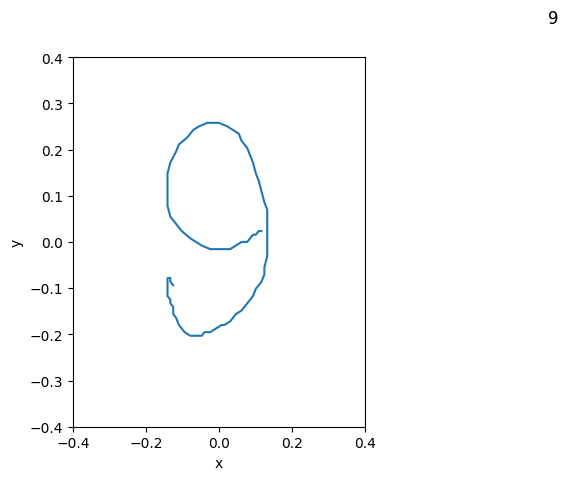

In [61]:
# Display a stroke from the strokes python variable
plot_stroke(strokes[46])

### Preprocess your Dataset
Next we'll preprocess the dataset to prepare it for training. By preprocessing the data in bulk before training the whole training process will execute much faster. To do so, we'll convert the strokes into rastered images using the helper functions below. This is the process used in real-time in the Arduino code to convert a gesture into an image that the CNN we are going to train can then process.

Once we have converted the dataset to rasterized images we will generate a ```Keras``` dataset for use in training.

In [58]:
FIXED_POINT = 256

def mul_fp(a, b):
  return (a * b) / FIXED_POINT

def div_fp(a, b):
  if b == 0:
    b = 1
  return (a * FIXED_POINT) / b

def float_to_fp(a):
  return math.floor(a * FIXED_POINT)

def norm_to_coord_fp(a, range_fp, half_size_fp):
  a_fp = float_to_fp(a)
  norm_fp = div_fp(a_fp, range_fp)
  return mul_fp(norm_fp, half_size_fp) + half_size_fp

def round_fp_to_int(a):
  return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)

def gate(a, min, max):
  if a < min:
    return min
  elif a > max:
    return max
  else:
    return a

def rasterize_stroke(stroke_points, x_range, y_range, width, height):
  num_channels = 3
  buffer_byte_count = height * width * num_channels
  buffer = bytearray(buffer_byte_count)

  width_fp = width * FIXED_POINT
  height_fp = height * FIXED_POINT
  half_width_fp = width_fp / 2
  half_height_fp = height_fp / 2
  x_range_fp = float_to_fp(x_range)
  y_range_fp = float_to_fp(y_range)

  t_inc_fp = FIXED_POINT / len(stroke_points)

  one_half_fp = (FIXED_POINT / 2)

  for point_index in range(len(stroke_points) - 1):
    start_point = stroke_points[point_index]
    end_point = stroke_points[point_index + 1]
    start_x_fp = norm_to_coord_fp(start_point["x"], x_range_fp, half_width_fp)
    start_y_fp = norm_to_coord_fp(-start_point["y"], y_range_fp, half_height_fp)
    end_x_fp = norm_to_coord_fp(end_point["x"], x_range_fp, half_width_fp)
    end_y_fp = norm_to_coord_fp(-end_point["y"], y_range_fp, half_height_fp)
    delta_x_fp = end_x_fp - start_x_fp
    delta_y_fp = end_y_fp - start_y_fp

    t_fp = point_index * t_inc_fp
    if t_fp < one_half_fp:
      local_t_fp = div_fp(t_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = round_fp_to_int(one_minus_t_fp * 255)
      green = round_fp_to_int(local_t_fp * 255)
      blue = 0
    else:
      local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = 0
      green = round_fp_to_int(one_minus_t_fp * 255)
      blue = round_fp_to_int(local_t_fp * 255)
    red = gate(red, 0, 255)
    green = gate(green, 0, 255)
    blue = gate(blue, 0, 255)

    if abs(delta_x_fp) > abs(delta_y_fp):
      line_length = abs(round_fp_to_int(delta_x_fp))
      if delta_x_fp > 0:
        x_inc_fp = 1 * FIXED_POINT
        y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
      else:
        x_inc_fp = -1 * FIXED_POINT
        y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
    else:
      line_length = abs(round_fp_to_int(delta_y_fp))
      if delta_y_fp > 0:
        y_inc_fp = 1 * FIXED_POINT
        x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
      else:
        y_inc_fp = -1 * FIXED_POINT
        x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)
    for i in range(line_length + 1):
      x_fp = start_x_fp + (i * x_inc_fp)
      y_fp = start_y_fp + (i * y_inc_fp)
      x = round_fp_to_int(x_fp)
      y = round_fp_to_int(y_fp)
      if (x < 0) or (x >= width) or (y < 0) or (y >= height):
        continue
      buffer_index = (y * width * num_channels) + (x * num_channels)
      buffer[buffer_index + 0] = red
      buffer[buffer_index + 1] = green
      buffer[buffer_index + 2] = blue

  np_buffer = np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)

  return np_buffer

In [57]:
X_RANGE = 0.6
Y_RANGE = 0.6

def ensure_empty_dir(dirname):
  dirpath = Path(dirname)
  if dirpath.exists() and dirpath.is_dir():
    shutil.rmtree(dirpath)
  dirpath.mkdir()

def augment_points(points, move_range, scale_range, rotate_range):
  move_x = np.random.uniform(low=-move_range, high=move_range)
  move_y = np.random.uniform(low=-move_range, high=move_range)
  scale = np.random.uniform(low=1.0-scale_range, high=1.0+scale_range)
  rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

  x_axis_x = math.cos(rotate) * scale
  x_axis_y = math.sin(rotate) * scale

  y_axis_x = -math.sin(rotate) * scale
  y_axis_y = math.cos(rotate) * scale

  new_points = []
  for point in points:
    old_x = point["x"]
    old_y = point["y"]
    new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
    new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
    new_points.append({"x": new_x, "y": new_y})

  return new_points

def save_strokes_as_images(strokes, root_folder, width, height, augment_count):
  ensure_empty_dir(root_folder)
  labels = set()
  for stroke in strokes:
    labels.add(stroke["label"].lower())
  for label in labels:
    label_path = Path(root_folder, label)
    ensure_empty_dir(label_path)

  label_counts = {}
  for stroke in strokes:
    points = stroke["strokePoints"]
    label = stroke["label"].lower()
    if label == "":
      raise Exception("Missing label for %s:%d" % (stroke["filename"], stroke["index"]))
    if label not in label_counts:
      label_counts[label] = 0
    label_count = label_counts[label]
    label_counts[label] += 1
    raster = rasterize_stroke(points, X_RANGE, Y_RANGE, width, height)
    image = PIL.Image.fromarray(raster)
    image.save(Path(root_folder, label, str(label_count) + ".png"))
    for i in range(augment_count):
      augmented_points = augment_points(points, 0.1, 0.1, 0.3)
      raster = rasterize_stroke(augmented_points, X_RANGE, Y_RANGE, width, height)
      image = PIL.Image.fromarray(raster)
      image.save(Path(root_folder, label, str(label_count) + "_a" + str(i) + ".png"))
  return labels

In [62]:
from collections import defaultdict
import random

# Group strokes by label
strokes_by_label = defaultdict(list)
for stroke in strokes:
    strokes_by_label[stroke["label"]].append(stroke)

# Find max class size
max_count = max(len(v) for v in strokes_by_label.values())

# Oversample
balanced_strokes = []

for label, label_strokes in strokes_by_label.items():
    current = len(label_strokes)

    if current < max_count:
        extra = random.choices(label_strokes, k=max_count - current)
        label_strokes = label_strokes + extra

    balanced_strokes.extend(label_strokes)

print("Balanced counts:")
for label in strokes_by_label:
    print(label, len([s for s in balanced_strokes if s["label"] == label]))

Balanced counts:
3 100
2 100
7 100
9 100
1 100
5 100
b 100
4 100
6 100
8 100
0 100


[link text](https://)Take the dataset and shuffle it into the Training/Validation/Test splits

In [63]:
IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32

shuffled_strokes = strokes
np.random.shuffle(shuffled_strokes)

test_count = math.floor((len(shuffled_strokes) * TEST_PERCENTAGE) / 100)
validation_count = math.floor((len(shuffled_strokes) * VALIDATION_PERCENTAGE) / 100)
test_strokes = shuffled_strokes[0:test_count]
validation_strokes = shuffled_strokes[test_count:(test_count + validation_count)]
train_strokes = shuffled_strokes[(test_count + validation_count):]

labels_test  = save_strokes_as_images(test_strokes, TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)
labels_val   = save_strokes_as_images(validation_strokes, VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)
labels_train = save_strokes_as_images(train_strokes, TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)

Also get the alphanumeric ordering of the labels as the Nueral Network will output its result in this order for the predicted class. **Make a note of this ordering as you will need to enter the labels in order in the Arduino code!**

In [64]:
labels = sorted(labels_test.union(labels_val).union(labels_train))
# get the conversion from label string to int
labelToInt = {}
currInt = 0
for label in labels:
  labelToInt[label] = currInt
  currInt = currInt + 1
intToLabel = {v: k for k, v in labelToInt.items()}
print(intToLabel)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'b'}


If you'd like to visualize the difference between a stroke and its rasterized output image, run the cell below!

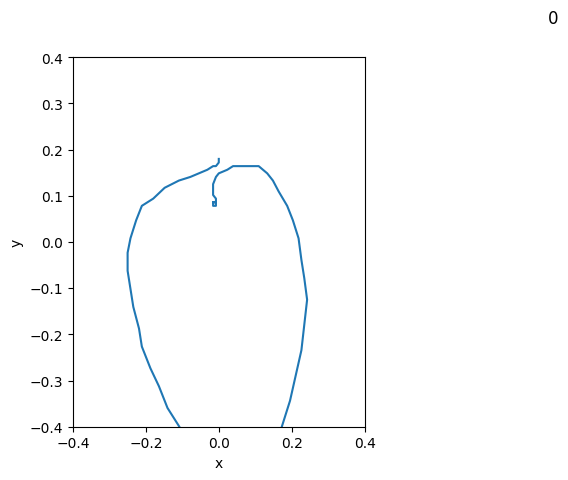

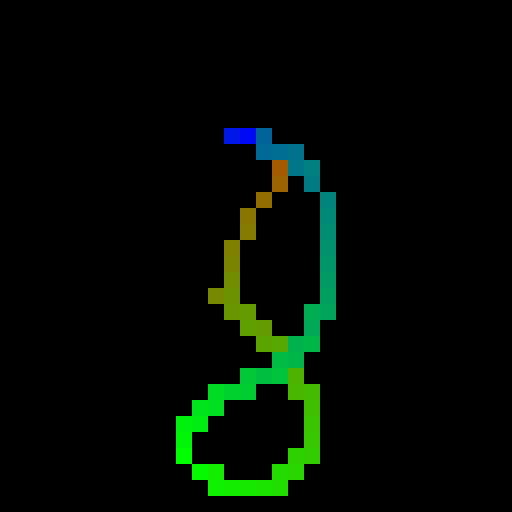

In [66]:
plot_stroke(strokes[90])
raster = rasterize_stroke(strokes[0]["strokePoints"], 0.5, 0.5, 32, 32)
PIL.Image.fromarray(raster).resize((512, 512), PIL.Image.NEAREST)

Finally, we'll generate a dataset in ```Keras```.

In [67]:
validation_ds = image_dataset_from_directory(
    directory=VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

train_ds = image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)


Found 3960 files belonging to 11 classes.
Found 7920 files belonging to 11 classes.


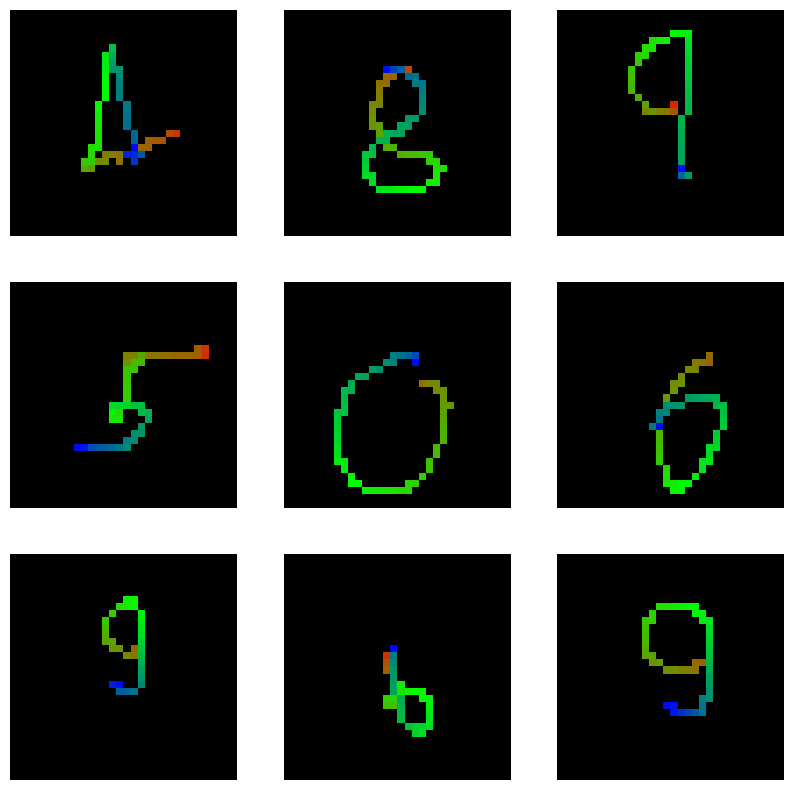

In [68]:
# Plot 9 of our final dataset items
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

## Define your Model

Next we will define and visualize the CNN model that we will use for the magic wand!

In [69]:
from tensorflow.keras import layers
def build_opt_model_3():
    model = keras.Sequential([
        layers.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)),

        # --- Layer 0 ---
        # filters_0: 8, kernel_0: 3
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.1), # dropout_0

        # --- Layer 1 ---
        # filters_1: 8, kernel_1: 5
        layers.Conv2D(8, (5, 5), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.0), # dropout_1

        # --- Transition & Output ---
        # Note: Depending on your 'use_gap' result, you'd use GAP or Flatten.
        # Most "Opt_Models" perform better with Flatten if size allows.
        layers.Flatten(),
        layers.Dense(NUM_GESTURES, activation="softmax")
    ], name="Opt_Model_3")

    # Use the specific Learning Rate from your results
    opt = keras.optimizers.Adam(learning_rate=0.0021963029380171572)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
model = build_opt_model_3()
# How many epochs to train for, we have found ~30 to be a good starting point
EPOCHS = 30

# Callback to save model checkpoints for future inspection or training
checkpointFileLoc = CHKPT_DIR + "/save_at_{epoch:02d}.h5"
modelCheckpointCallback = keras.callbacks.ModelCheckpoint(checkpointFileLoc)

# Run training
history = model.fit(train_ds, epochs=EPOCHS, validation_data=validation_ds,
                    callbacks=[modelCheckpointCallback])

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6780 - loss: 1.0192

248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8539 - loss: 0.4876 - val_accuracy: 0.9664 - val_loss: 0.1271
Epoch 2/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9747 - loss: 0.0918

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9828 - loss: 0.0683 - val_accuracy: 0.9841 - val_loss: 0.0736
Epoch 3/30
240/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9908 - loss: 0.0370

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9932 - loss: 0.0300 - val_accuracy: 0.9846 - val_loss: 0.0653
Epoch 4/30
242/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9960 - loss: 0.0166

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9972 - loss: 0.0136 - val_accuracy: 0.9889 - val_loss: 0.0598
Epoch 5/30
246/248 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0098

...

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 1.9069e-04 - val_accuracy: 0.9932 - val_loss: 0.0801
Epoch 27/30
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.0472e-04

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 8.9354e-05 - val_accuracy: 0.9934 - val_loss: 0.0830
Epoch 28/30
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9976 - loss: 0.0101

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9971 - loss: 0.0125 - val_accuracy: 0.9902 - val_loss: 0.1148
Epoch 29/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9996 - loss: 0.0014

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9912 - val_loss: 0.1007
Epoch 30/30
235/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9999 - loss: 7.6367e-04

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9866 - val_loss: 0.1256


In [77]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(16, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    x = layers.GlobalAveragePooling2D()(x)
    activation = "softmax"
    units = num_classes

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(units, activation=activation)(x)
    return keras.Model(inputs, outputs)

model = make_model(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES)

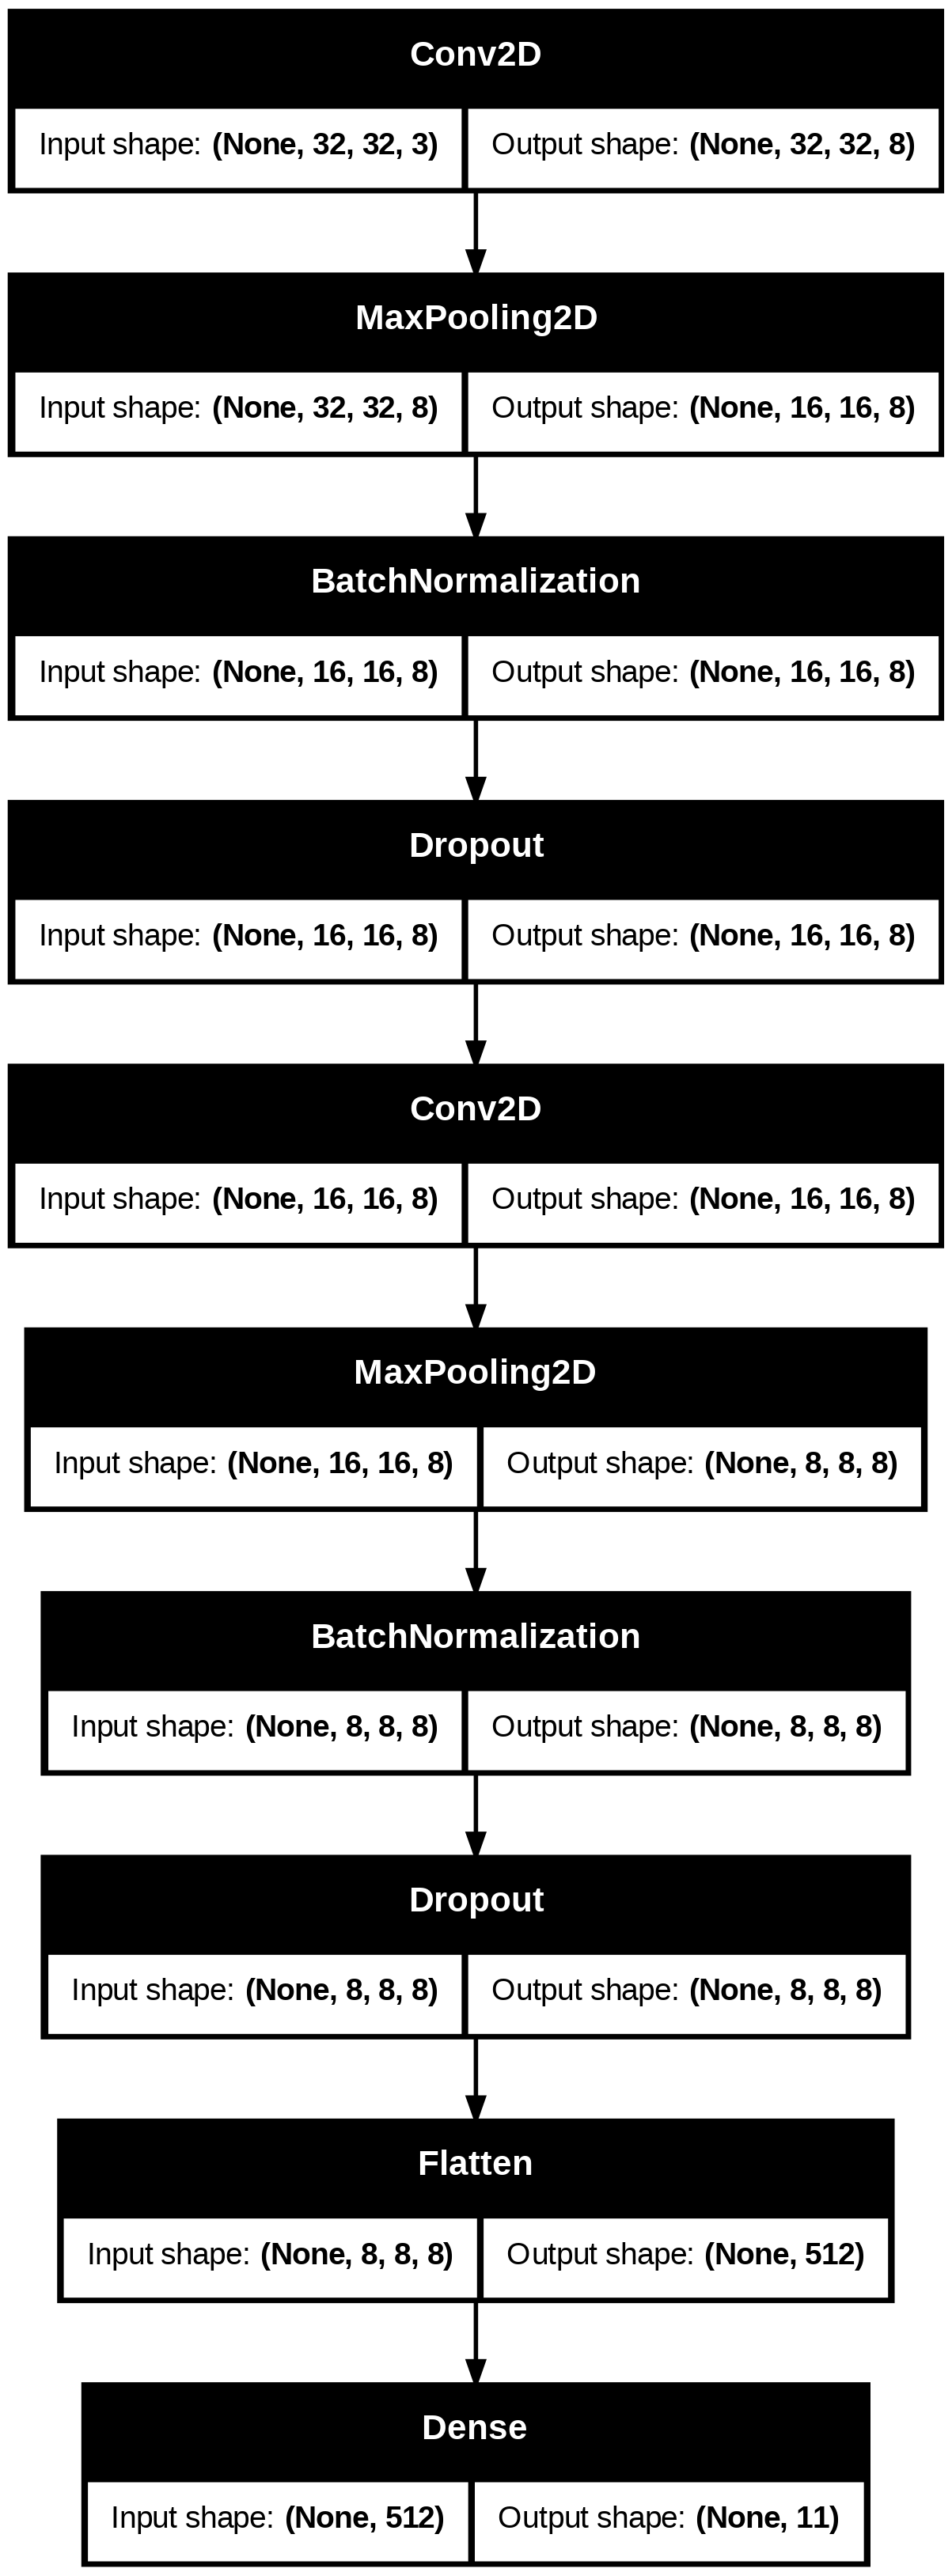

In [70]:
# View the model layers as a diagram
keras.utils.plot_model(model, show_shapes=True)

## Train your Model

Now that we have a preprocessed dataset and a model its time to train that model with that dataset!

In [78]:
# How many epochs to train for, we have found ~30 to be a good starting point
EPOCHS = 30

# Callback to save model checkpoints for future inspection or training
checkpointFileLoc = CHKPT_DIR + "/save_at_{epoch:02d}.h5"
modelCheckpointCallback = keras.callbacks.ModelCheckpoint(checkpointFileLoc)

# Compile the model!
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Run training
history = model.fit(train_ds, epochs=EPOCHS, validation_data=validation_ds,
                    callbacks=[modelCheckpointCallback])

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0996 - loss: 0.5749

248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.1059 - loss: 0.4531 - val_accuracy: 0.0909 - val_loss: 0.3295
Epoch 2/30
242/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1247 - loss: 0.3233

248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1324 - loss: 0.3179 - val_accuracy: 0.1629 - val_loss: 0.3090
Epoch 3/30
245/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1677 - loss: 0.3069

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1713 - loss: 0.3043 - val_accuracy: 0.3364 - val_loss: 0.2821
Epoch 4/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1944 - loss: 0.2956

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2083 - loss: 0.2925 - val_accuracy: 0.4371 - val_loss: 0.2675
Epoch 5/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2448 - loss: 0.2865

...

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5856 - loss: 0.1875 - val_accuracy: 0.9227 - val_loss: 0.1267
Epoch 27/30
244/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5980 - loss: 0.1842

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6085 - loss: 0.1833 - val_accuracy: 0.9232 - val_loss: 0.1247
Epoch 28/30
233/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6073 - loss: 0.1829

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6143 - loss: 0.1810 - val_accuracy: 0.9247 - val_loss: 0.1199
Epoch 29/30
240/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5973 - loss: 0.1860

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6131 - loss: 0.1834 - val_accuracy: 0.9247 - val_loss: 0.1194
Epoch 30/30
234/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6260 - loss: 0.1804

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6251 - loss: 0.1801 - val_accuracy: 0.9298 - val_loss: 0.1193


In [79]:
val_loss, val_accuracy = model.evaluate(validation_ds)
print(f"Test Loss: {val_loss:.4f}")
print(f"Test Accuracy: {val_accuracy:.4f}")


124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9298 - loss: 0.1193
Test Loss: 0.1193
Test Accuracy: 0.9298


Now, let's evaluate the model on the test dataset.

In [80]:
test_ds = image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Found 1320 files belonging to 11 classes.
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9273 - loss: 0.1174
Test Loss: 0.1174
Test Accuracy: 0.9273


In [49]:
# save the model file
model.save(SAVED_MODEL_FILENAME)

## Consistency metric

In [85]:
import numpy as np
import glob
import os

def compute_consistency_for_class(model, class_label, test_dir):
    scores = []

    class_path = os.path.join(test_dir, class_label)
    files = glob.glob(class_path + "/*.png")

    print(f"Evaluating consistency for class '{class_label}' ({len(files)} samples)")

    for filename in files:
        _, score = predict_image(model, filename)
        scores.append(score)

    mean_score = np.mean(scores)
    std_score = np.std(scores)

    print(f"\nMean confidence: {mean_score:.3f}")
    print(f"Std deviation : {std_score:.3f}")

    return mean_score, std_score

mean_b, std_b = compute_consistency_for_class(model, "b", TEST_DIR)

Evaluating consistency for class 'b' (108 samples)

Mean confidence: 0.642
Std deviation : 0.203


Generating predictions for normalized confusion matrix...


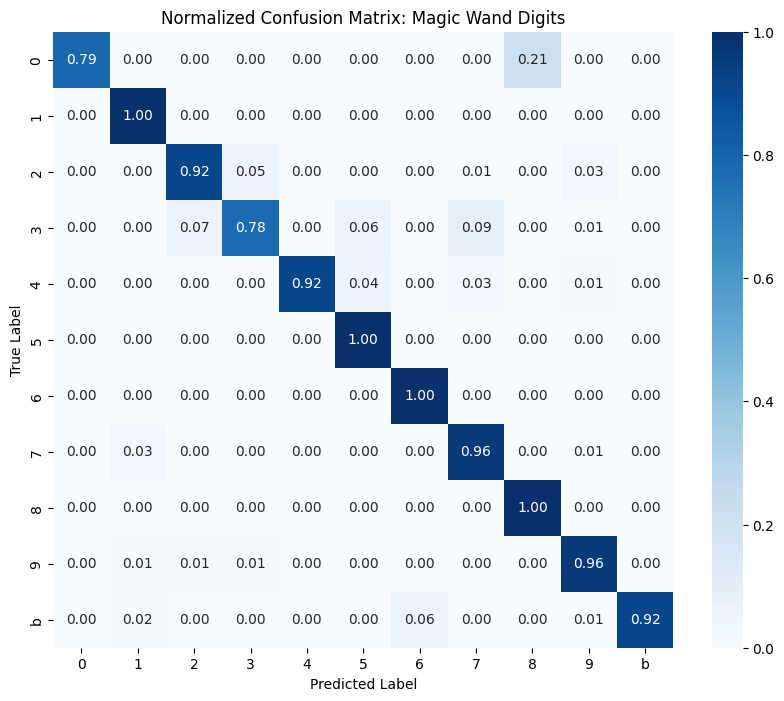

🔎 Insight: The largest normalized confusion is True Class '0' predicted as '8' (0.21).

Macro F1 Score   : 0.927
Weighted F1 Score: 0.926

Per-class F1 Scores:
0: 0.881
1: 0.976
2: 0.926
3: 0.842
4: 0.957
5: 0.954
6: 0.952
7: 0.912
8: 0.911
9: 0.931
b: 0.957
F1 score for b: 0.957


In [86]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score

def plot_normalized_confusion_matrix(model, dataset, class_names):
    all_preds = []
    all_labels = []

    print("Generating predictions for normalized confusion matrix...")

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(np.argmax(labels.numpy(), axis=1))

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = confusion_matrix(all_labels, all_preds, normalize='true')

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Normalized Confusion Matrix: Magic Wand Digits')
    plt.show()

    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    most_confused_idx = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

    print(
        f"🔎 Insight: The largest normalized confusion is True Class "
        f"'{class_names[most_confused_idx[0]]}' predicted as "
        f"'{class_names[most_confused_idx[1]]}' "
        f"({cm_no_diag[most_confused_idx]:.2f})."
    )

    # F1 scores
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    per_class_f1 = f1_score(all_labels, all_preds, average=None)

    print(f"\nMacro F1 Score   : {macro_f1:.3f}")
    print(f"Weighted F1 Score: {weighted_f1:.3f}")

    print("\nPer-class F1 Scores:")
    for i, score in enumerate(per_class_f1):
        print(f"{class_names[i]}: {score:.3f}")

    return cm, macro_f1, weighted_f1, per_class_f1

class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'b']

cm, macro_f1, weighted_f1, per_class_f1 = plot_normalized_confusion_matrix(model, test_ds, class_names)

b_index = class_names.index('b')
print(f"F1 score for b: {per_class_f1[b_index]:.3f}")

In [ ]:
from tensorflow.keras import layers
def build_opt_model_3():
    model = keras.Sequential([
        layers.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)),

        # --- Layer 0 ---
        # filters_0: 8, kernel_0: 3
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.1), # dropout_0

        # --- Layer 1 ---
        # filters_1: 8, kernel_1: 5
        layers.Conv2D(8, (5, 5), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.0), # dropout_1

        # --- Transition & Output ---
        # Note: Depending on your 'use_gap' result, you'd use GAP or Flatten.
        # Most "Opt_Models" perform better with Flatten if size allows.
        layers.Flatten(),
        layers.Dense(NUM_GESTURES, activation="softmax")
    ], name="Opt_Model_3")

    # Use the specific Learning Rate from your results
    opt = keras.optimizers.Adam(learning_rate=0.0021963029380171572)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
model = build_opt_model_3()
# How many epochs to train for, we have found ~30 to be a good starting point
EPOCHS = 30

# Callback to save model checkpoints for future inspection or training
checkpointFileLoc = CHKPT_DIR + "/save_at_{epoch:02d}.h5"
modelCheckpointCallback = keras.callbacks.ModelCheckpoint(checkpointFileLoc)

# Run training
history = model.fit(train_ds, epochs=EPOCHS, validation_data=validation_ds,
                    callbacks=[modelCheckpointCallback])

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7049 - loss: 0.9483

248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8644 - loss: 0.4506 - val_accuracy: 0.9624 - val_loss: 0.1278
Epoch 2/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0770

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9848 - loss: 0.0595 - val_accuracy: 0.9803 - val_loss: 0.0690
Epoch 3/30
246/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9887 - loss: 0.0373

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9920 - loss: 0.0296 - val_accuracy: 0.9821 - val_loss: 0.0569
Epoch 4/30
243/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9937 - loss: 0.0200

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9953 - loss: 0.0170 - val_accuracy: 0.9866 - val_loss: 0.0496
Epoch 5/30
236/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9961 - loss: 0.0144

...

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.9876 - val_loss: 0.0888
Epoch 27/30
240/248 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9990 - loss: 0.0043

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9884 - val_loss: 0.0746
Epoch 28/30
236/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9996 - loss: 0.0012

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9997 - loss: 8.2370e-04 - val_accuracy: 0.9919 - val_loss: 0.0516
Epoch 29/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0014

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9989 - loss: 0.0025 - val_accuracy: 0.9876 - val_loss: 0.0671
Epoch 30/30
240/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0023

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9896 - val_loss: 0.0782


In [ ]:
from tensorflow.keras import layers
def build_opt_model_3():
    model = keras.Sequential([
        layers.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)),

        # --- Layer 0 ---
        # filters_0: 8, kernel_0: 3
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.1), # dropout_0

        # --- Layer 1 ---
        # filters_1: 8, kernel_1: 5
        layers.Conv2D(8, (5, 5), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.0), # dropout_1

        # --- Transition & Output ---
        # Note: Depending on your 'use_gap' result, you'd use GAP or Flatten.
        # Most "Opt_Models" perform better with Flatten if size allows.
        layers.Flatten(),
        layers.Dense(NUM_GESTURES, activation="softmax")
    ], name="Opt_Model_3")

    # Use the specific Learning Rate from your results
    opt = keras.optimizers.Adam(learning_rate=0.0021963029380171572)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
model = build_opt_model_3()
# How many epochs to train for, we have found ~30 to be a good starting point
EPOCHS = 30

# Callback to save model checkpoints for future inspection or training
checkpointFileLoc = CHKPT_DIR + "/save_at_{epoch:02d}.h5"
modelCheckpointCallback = keras.callbacks.ModelCheckpoint(checkpointFileLoc)

# Run training
history = model.fit(train_ds, epochs=EPOCHS, validation_data=validation_ds,
                    callbacks=[modelCheckpointCallback])

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7049 - loss: 0.9483

248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8644 - loss: 0.4506 - val_accuracy: 0.9624 - val_loss: 0.1278
Epoch 2/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0770

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9848 - loss: 0.0595 - val_accuracy: 0.9803 - val_loss: 0.0690
Epoch 3/30
246/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9887 - loss: 0.0373

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9920 - loss: 0.0296 - val_accuracy: 0.9821 - val_loss: 0.0569
Epoch 4/30
243/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9937 - loss: 0.0200

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9953 - loss: 0.0170 - val_accuracy: 0.9866 - val_loss: 0.0496
Epoch 5/30
236/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9961 - loss: 0.0144

...

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.9876 - val_loss: 0.0888
Epoch 27/30
240/248 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9990 - loss: 0.0043

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9884 - val_loss: 0.0746
Epoch 28/30
236/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9996 - loss: 0.0012

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9997 - loss: 8.2370e-04 - val_accuracy: 0.9919 - val_loss: 0.0516
Epoch 29/30
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0014

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9989 - loss: 0.0025 - val_accuracy: 0.9876 - val_loss: 0.0671
Epoch 30/30
240/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0023

248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9896 - val_loss: 0.0782


## Test your TensorFlow Model

Lets now test out the TF model on the test dataset. We'll print out any gesture we get wrong as well as the percentage of known gestures correct as well as the number of gestures that were marked as unknown.

In [ ]:
SCORE_THRESHOLD = 0.75 # Confidence threshold to discard an image as "unknown"

def predict_image(model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)  # Create batch axis
  predictions = model.predict(img_array).flatten()
  predicted_label_index = np.argmax(predictions)
  predicted_score = predictions[predicted_label_index]
  return (predicted_label_index, predicted_score)

correct_count = 0
wrong_count = 0
discarded_count = 0
for label_dir in glob.glob(TEST_DIR + "/*"):
  label = label_dir.replace(TEST_DIR + "/", "")
  print("Testing Gesture: ",label," with datasize: ",len(glob.glob(label_dir + "/*.png")))
  for filename in glob.glob(label_dir + "/*.png"):
    index, score = predict_image(model, filename)
    if score < SCORE_THRESHOLD:
      discarded_count += 1
      continue
    if index == labelToInt[label]:
      correct_count += 1
    else:
      wrong_count += 1
      print(label,index,score)
      print("[%s] expected, [%s] found with score [%f]" % (label, intToLabel[index], score))
      display(Image(filename=filename))

if correct_count + wrong_count == 0:
  print("All images marked as unknown!")
else:
  correct_percentage = (correct_count / (correct_count + wrong_count)) * 100
  print("%.1f%% correct (N=%d, %d unknown)" % (correct_percentage, (correct_count + wrong_count), discarded_count))

Testing Gesture:  9  with datasize:  99
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━

If you'd like to manually evaluate particular images you can uncomment, update, and run the below cell and select an image from the test folder.

In [ ]:
# TEST_IMAGE = # UPDATE ME e.g., "test/0/1.png"
# index, score = predict_image(model, TEST_IMAGE)
# print(index, score) # prints the guessed index and the confidence

## Generate a TensorFlow Lite Model

Convert the frozen graph into a TensorFlow Lite model, which is fully quantized for use with embedded devices. The following cell will also print the model size.

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
model_no_quant_tflite = converter.convert()

# Save the model to disk
open(FLOAT_TFL_MODEL_FILENAME, "wb").write(model_no_quant_tflite)

def representative_dataset():
  for filename in glob.glob(TEST_DIR + "/*/*.png"):
    img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis for images, labels in train_ds.take(1):
    yield([img_array])
# Set the optimization flag.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Enforce integer only quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
# Provide a representative dataset to ensure we quantize correctly.
converter.representative_dataset = representative_dataset
model_tflite = converter.convert()

# Save the model to disk
open(QUANTIZED_TFL_MODEL_FILENAME, "wb").write(model_tflite)

Saved artifact at '/tmp/tmpxa8s3pvn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_17')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136142409583120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409584080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409585040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409586000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409585808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409585232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409586384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409586192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409587536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409587728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136142409584

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


21312

Compare the sizes of the Tensorflow, TensorFlow Lite and Quantized TensorFlow Lite models.

In [ ]:
def get_dir_size(dir):
  size = 0
  for f in os.scandir(dir):
    if f.is_file():
      size += f.stat().st_size
    elif f.is_dir():
      size += get_dir_size(f.path)
  return size

# Calculate size
size_tf = os.path.getsize(SAVED_MODEL_FILENAME)
size_no_quant_tflite = os.path.getsize(FLOAT_TFL_MODEL_FILENAME)
size_tflite = os.path.getsize(QUANTIZED_TFL_MODEL_FILENAME)

# Compare size
pd.DataFrame.from_records(
    [["TensorFlow", f"{size_tf} bytes", ""],
     ["TensorFlow Lite", f"{size_no_quant_tflite} bytes ", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
     ["TensorFlow Lite Quantized", f"{size_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_tflite} bytes)"]],
     columns = ["Model", "Size", ""], index="Model")

,Size,
Model,,
TensorFlow,252031 bytes,
TensorFlow Lite,62744 bytes,(reduced by 189287 bytes)
TensorFlow Lite Quantized,21312 bytes,(reduced by 41432 bytes)


## Test your TensorFlow Lite Models

Lets now test out the TFLite models (quantized and unquantized) on the test dataset. We'll print out any gesture we get wrong as well as the percentage of known gestures correct as well as the number of gestures that were marked as unknown.

In [ ]:
def predict_tflite(tflite_model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

  # Initialize the TFLite interpreter
  interpreter = tf.lite.Interpreter(model_content=tflite_model)
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()[0]
  output_details = interpreter.get_output_details()[0]

  # If required, quantize the input layer (from float to integer)
  input_scale, input_zero_point = input_details["quantization"]
  if (input_scale, input_zero_point) != (0.0, 0):
    img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
    img_array = img_array.astype(input_details["dtype"])

  # Invoke the interpreter
  interpreter.set_tensor(input_details["index"], img_array)
  interpreter.invoke()
  pred = interpreter.get_tensor(output_details["index"])[0]

  # If required, dequantized the output layer (from integer to float)
  output_scale, output_zero_point = output_details["quantization"]
  if (output_scale, output_zero_point) != (0.0, 0):
    pred = pred.astype(np.float32)
    pred = np.multiply((pred - output_zero_point), output_scale)

  predicted_label_index = np.argmax(pred)
  predicted_score = pred[predicted_label_index]
  return (predicted_label_index, predicted_score)

In [ ]:
def run_tflite_test(model_file):
  correct_count = 0
  wrong_count = 0
  discarded_count = 0
  for label_dir in glob.glob(TEST_DIR + "/*"):
    label = label_dir.replace(TEST_DIR + "/", "")
    print("Testing Gesture: ",label," with datasize: ",len(glob.glob(label_dir + "/*.png")))
    for filename in glob.glob(label_dir + "/*.png"):
      index, score = predict_tflite(model_file, filename)
      if score < 0.75:
        discarded_count += 1
        continue
      if index == labelToInt[label]:
        correct_count += 1
      else:
        wrong_count += 1
        print("[%s] expected, [%s] found with score [%f]" % (label, intToLabel[index], score))
        display(Image(filename=filename))

  correct_percentage = (correct_count / (correct_count + wrong_count)) * 100

  print("%.1f%% correct (N=%d, %d unknown)" % (correct_percentage, (correct_count + wrong_count), discarded_count))

First test the float model.

In [ ]:
run_tflite_test(model_no_quant_tflite)

Testing Gesture:  9  with datasize:  99
Testing Gesture:  4  with datasize:  176


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Testing Gesture:  5  with datasize:  121
Testing Gesture:  2  with datasize:  33
Testing Gesture:  1  with datasize:  154
Testing Gesture:  8  with datasize:  121
Testing Gesture:  6  with datasize:  110
Testing Gesture:  7  with datasize:  66
Testing Gesture:  3  with datasize:  99
Testing Gesture:  0  with datasize:  121
100.0% correct (N=503, 597 unknown)


Then test the quantized model

In [ ]:
run_tflite_test(model_tflite)

Testing Gesture:  9  with datasize:  99
Testing Gesture:  4  with datasize:  176
Testing Gesture:  5  with datasize:  121
Testing Gesture:  2  with datasize:  33
Testing Gesture:  1  with datasize:  154
Testing Gesture:  8  with datasize:  121
Testing Gesture:  6  with datasize:  110
Testing Gesture:  7  with datasize:  66
Testing Gesture:  3  with datasize:  99
Testing Gesture:  0  with datasize:  121
100.0% correct (N=503, 597 unknown)


If you'd like to manually evaluate particular images you can uncomment, update, and run the below cell and select an image from the test folder.

In [ ]:
# TEST_IMAGE = # UPDATE ME e.g., "test/0/1.png"
# index, score = predict_tflite(model_no_quant_tflite, TEST_IMAGE)
# print("Float model result:")
# print(index, score) # prints the guessed index and the confidence
# index, score = predict_tflite(model_tflite, TEST_IMAGE)
# print("Quantized model result:")
# print(index, score) # prints the guessed index and the confidence

## Generate a TensorFlow Lite for Microcontrollers Model
To convert the TensorFlow Lite quantized model into a C source file that can be loaded by TensorFlow Lite for Microcontrollers on Arduino we simply need to use the ```xxd``` tool to convert the ```.tflite``` file into a ```.cc``` file.

In [ ]:
# Convert to a C source file, i.e, a TensorFlow Lite for Microcontrollers model
!xxd -i {QUANTIZED_TFL_MODEL_FILENAME} > {TFL_CC_MODEL_FILENAME}
# Update variable names
REPLACE_TEXT = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')
!sed -i 's/'{REPLACE_TEXT}'/g_magic_wand_model_data/g' {TFL_CC_MODEL_FILENAME}

That's it! You've successfully converted your TensorFlow Lite model into a TensorFlow Lite for Microcontrollers model! Run the cell below to print out its contents which we'll need for our next step, deploying the model using the Arudino IDE!

In [ ]:
# Print the C source file
!cat {TFL_CC_MODEL_FILENAME}
# !tail {TFL_CC_MODEL_FILENAME} # run this command to just see the end of the file (aka the size)

unsigned char g_magic_wand_model_data[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x98, 0x00, 0x00, 0x00, 0x18, 0x01, 0x00, 0x00,
  0xf8, 0x3c, 0x00, 0x00, 0x08, 0x3d, 0x00, 0x00, 0xa8, 0x52, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00,
  0x00, 0x00, 0x0a, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x08, 0x00, 0x04, 0x00,
  0x0a, 0x00, 0x00, 0x00, 0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x3c, 0x00, 0x00, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76,
  0x69, 0x6e, 0x67, 0x5f, 0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x68, 0xff, 0xff, 0xff,
  0x0f, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00,
  0x6f, 0x75, 0x74, 0x70, 0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 

To download your model for use at a later date:

1. On the left of the UI click on the folder icon
2. Click on the three dots to the right of the ```.cc``` file you just generated and select "download." The file can be found at ```models/{TFL_CC_MODEL_FILENAME}``` which by default is ```models/magic_wand.cc```

Next we'll deploy that model using the Arduino IDE.